In [102]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import (
    precision_recall_curve,
    f1_score,
    accuracy_score,
    confusion_matrix
)


In [168]:
THRESHOLD = 0.475

FOLD_PATHS = [
    "Queries/Individual_Candidate_Query_1.csv",
    "Queries/Individual_Candidate_Query_2.csv",
    "Queries/Individual_Candidate_Query_3.csv",
    "Queries/Individual_Candidate_Query_4.csv",
    "Queries/Individual_Candidate_Query_5.csv",
]


In [169]:

DROP_COLS = [
    "Win",
    "general_election_result",
    "general_votes_received",
    "total_general_votes_cast",
    "viability_score",
    "election_date"
]

# -----------------------
# Viability (0–5) + bucket labels (1–5 categories)
# -----------------------
VIAB_LABELS = ["No Chance", "Unlikely to Win", "Has a Chance", "Likely to Win", "Frontrunner"]

def proba_to_viability_score(proba: np.ndarray) -> np.ndarray:
    return 5.0 * proba

def viability_score_to_bucket(v: np.ndarray) -> pd.Categorical:
    return pd.cut(
        v,
        bins=[0, 1, 2, 3, 4, 5],
        labels=VIAB_LABELS,
        right=False,
        include_lowest=True
    )

def prep(df: pd.DataFrame):
    # target
    df = df.copy()
    #df["Win"] = (df["general_election_result"] == "Won General").astype(int)
    df["election_date"] = pd.to_datetime(df["election_date"], errors="coerce")

    # simple components
    df["election_year"]  = df["election_date"].dt.year
    df["election_month"] = df["election_date"].dt.month
    df["election_doy"]   = df["election_date"].dt.dayofyear
    df["is_midterm"] = ((df["election_year"] % 4 != 0) & (df["election_year"] % 2 == 0)).astype(int)
    df["is_presidential"] = (df["election_year"] % 4 == 0).astype(int)


    y = df["Win"].astype(int)
    X = df.drop(columns=DROP_COLS, errors="ignore")

    return X, y





In [170]:
# -----------------------
# Define pipelines ONCE (reused each fold)
# -----------------------
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

In [171]:
# -----------------------
# Load folds
# -----------------------
fold_dfs = [pd.read_csv(p) for p in FOLD_PATHS]

# normalize ids
fold_sets = [
    set(df["hubspot_id"].astype(str).str.strip())
    for df in fold_dfs
]
total_overlap = 0
for i in range(len(fold_sets)):
    for j in range(i + 1, len(fold_sets)):
        inter = fold_sets[i].intersection(fold_sets[j])
        if inter:
            print(f"Overlap between fold {i} and {j}: {len(inter)} hubspot_id(s)")
            total_overlap += len(inter)

print("Total cross-fold hubspot_id overlap:", total_overlap)

Total cross-fold hubspot_id overlap: 0


In [172]:
# -----------------------
# Batch-as-fold CV
# -----------------------
K = len(fold_dfs)
fold_aucs = []

y_all = []
proba_all = []
rows_all = [] 
coef_series_list = []


for k in range(K):
    test_df = fold_dfs[k].copy()
    train_df = pd.concat([fold_dfs[i] for i in range(K) if i != k], ignore_index=True)

    X_train, y_train = prep(train_df)
    X_test,  y_test  = prep(test_df)

    # IMPORTANT: compute column lists from THIS fold's training data
    num_cols = X_train.select_dtypes(include=["number"]).columns
    cat_cols = X_train.select_dtypes(exclude=["number"]).columns

    preprocess = ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ])

    clf = Pipeline([
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=2000)),
    ])

    clf.fit(X_train, y_train)

    # ---- collect per-fold feature importances (coef) ----
    pre = clf.named_steps["preprocess"]
    model = clf.named_steps["model"]

    # numeric feature names
    num_names = list(pre.named_transformers_["num"].feature_names_in_) \
        if hasattr(pre.named_transformers_["num"], "feature_names_in_") else list(num_cols)

    # categorical feature names after one-hot
    ohe = pre.named_transformers_["cat"].named_steps["onehot"]
    cat_names = ohe.get_feature_names_out(cat_cols)

    feature_names = np.r_[num_names, cat_names]
    coefs = model.coef_.ravel()

    coef_series_list.append(pd.Series(coefs, index=feature_names, name=f"fold_{k}"))


    proba = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    fold_aucs.append(auc)

    pred = (proba >= THRESHOLD).astype(int)
    cm = confusion_matrix(y_test, pred)

    print(f"\nFold {k+1}/{K} ROC-AUC: {auc:.4f}")
    print("Confusion matrix:\n", cm)

    y_all.append(y_test.to_numpy())
    proba_all.append(proba)

    # attach predictions back to the original (un-prepped) test rows
    scored = test_df.copy()
    scored["proba_win"] = proba
    scored["pred_win"] = pred
    rows_all.append(scored)




Fold 1/5 ROC-AUC: 0.7713
Confusion matrix:
 [[329 158]
 [139 374]]

Fold 2/5 ROC-AUC: 0.7638
Confusion matrix:
 [[335 154]
 [147 364]]

Fold 3/5 ROC-AUC: 0.7692
Confusion matrix:
 [[346 152]
 [158 344]]

Fold 4/5 ROC-AUC: 0.7621
Confusion matrix:
 [[321 173]
 [150 356]]

Fold 5/5 ROC-AUC: 0.7577
Confusion matrix:
 [[361 154]
 [161 324]]


In [173]:
# -----------------------
# Aggregate metrics
# -----------------------
y_all = np.concatenate(y_all)
proba_all = np.concatenate(proba_all)
pred_all = (proba_all >= THRESHOLD).astype(int)

print("\n============================")
print("5-Fold Batch-CV Summary")
print("============================")
print("Fold AUCs:", [round(a, 4) for a in fold_aucs])
print("Mean AUC :", float(np.mean(fold_aucs)))
print("Std AUC  :", float(np.std(fold_aucs)))

print("\nPooled ROC-AUC:", roc_auc_score(y_all, proba_all))
print("Pooled confusion matrix:\n", confusion_matrix(y_all, pred_all))
print(classification_report(y_all, pred_all))







5-Fold Batch-CV Summary
Fold AUCs: [0.7713, 0.7638, 0.7692, 0.7621, 0.7577]
Mean AUC : 0.7648270173181099
Std AUC  : 0.004898919451543522

Pooled ROC-AUC: 0.7649636919211145
Pooled confusion matrix:
 [[1692  791]
 [ 755 1762]]
              precision    recall  f1-score   support

           0       0.69      0.68      0.69      2483
           1       0.69      0.70      0.70      2517

    accuracy                           0.69      5000
   macro avg       0.69      0.69      0.69      5000
weighted avg       0.69      0.69      0.69      5000



In [174]:
# -----------------------
# Build results dataframe w/ viability (0–5) and 1–5 bucket classification
# -----------------------
results = pd.concat(rows_all, ignore_index=True)

results["viability_score_model"] = proba_to_viability_score(results["proba_win"].to_numpy())
results["viability_bucket_model"] = viability_score_to_bucket(results["viability_score_model"].to_numpy())
results["viability_bucket_num"] = results["viability_bucket_model"].cat.codes + 1  # 1..5

print("\nViability bucket distribution (model):")
print(results["viability_bucket_model"].value_counts(dropna=False))

# Example preview
print("\nSample scored rows:")
print(results[[
    "hubspot_id",
    "proba_win",
    "pred_win",
    "viability_score_model",
    "viability_bucket_num",
    "viability_bucket_model"
]].head(20).to_string(index=False))


Viability bucket distribution (model):
viability_bucket_model
Unlikely to Win    1316
Has a Chance       1278
Likely to Win      1011
Frontrunner         796
No Chance           599
Name: count, dtype: int64

Sample scored rows:
 hubspot_id  proba_win  pred_win  viability_score_model  viability_bucket_num viability_bucket_model
23615574793   0.850016         1               4.250081                     5            Frontrunner
43744745534   0.458630         0               2.293149                     3           Has a Chance
32162973274   0.582095         1               2.910476                     3           Has a Chance
36263502943   0.259359         0               1.296797                     2        Unlikely to Win
32766891889   0.953524         1               4.767619                     5            Frontrunner
23810996131   0.932185         1               4.660926                     5            Frontrunner
31179237553   0.810516         1               4.052578        

In [175]:
# ======================== Fold-averaged Feature Importance =========================
# Align features across folds (union), fill missing with 0
coef_df = pd.concat(coef_series_list, axis=1).fillna(0.0)  # rows=features, cols=folds

imp = pd.DataFrame({
    "mean_coef": coef_df.mean(axis=1),
    "std_coef": coef_df.std(axis=1),
    "mean_abs_coef": coef_df.abs().mean(axis=1),
    "sign_consistency": (np.sign(coef_df).replace(0, np.nan).mean(axis=1)).abs()
}).sort_values("mean_abs_coef", ascending=False)

# Top features overall (by average absolute effect)
print("\nTop 25 features by mean absolute coefficient across folds:")
print(imp.head(25).to_string())

# Top positive and negative on average
print("\nTop 25 features pushing toward Win=1 on average:")
print(imp.sort_values("mean_coef", ascending=False).head(25)[["mean_coef","std_coef","mean_abs_coef","sign_consistency"]].to_string())

print("\nTop 25 features pushing toward Win=0 on average:")
print(imp.sort_values("mean_coef", ascending=True).head(25)[["mean_coef","std_coef","mean_abs_coef","sign_consistency"]].to_string())



Top 25 features by mean absolute coefficient across folds:
                                                           mean_coef  std_coef  mean_abs_coef  sign_consistency
candidate_office_Town Council                              -1.271913  0.297970       1.271913               1.0
office_level_Unknown                                       -1.256155  0.224289       1.256155               1.0
candidate_office_Unknown                                    1.073372  0.720198       1.155939               0.6
state_New Hampshire                                         1.110716  0.185460       1.110716               1.0
candidate_office_Sky Valley City Mayor                      1.032785  0.300732       1.032785               1.0
candidate_office_Trustee                                    1.007881  0.239162       1.007881               1.0
office_type_Unknown                                        -0.948291  0.098560       0.948291               1.0
candidate_office_Wake Forest Town Council   

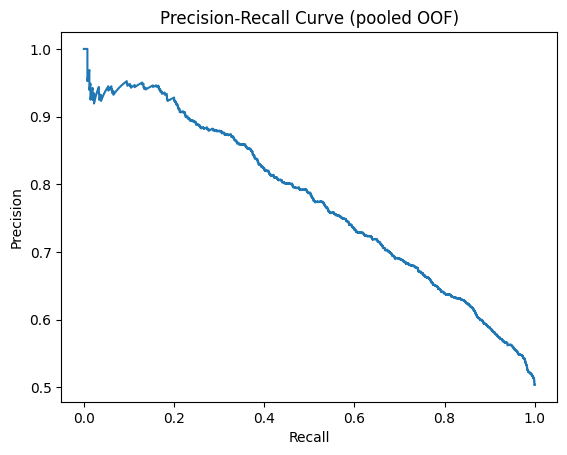

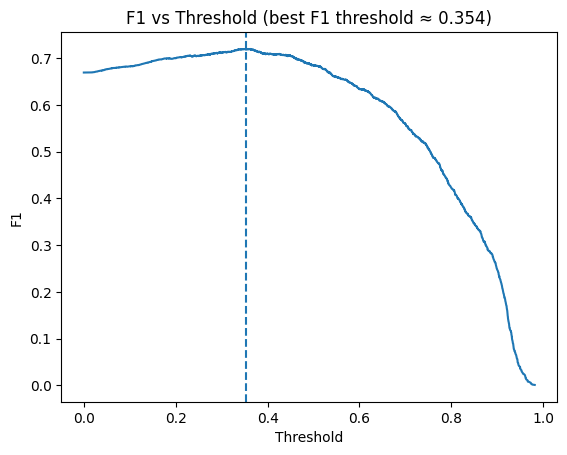

Best threshold by F1: 0.353726547474182


In [159]:
# -----------------------------
# 1) Precision-Recall curve + F1-optimal threshold
# -----------------------------
precision, recall, thresholds = precision_recall_curve(y_all, proba_all)
f1s = 2 * (precision * recall) / (precision + recall + 1e-12)

best_idx = np.nanargmax(f1s)
best_t_f1 = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (pooled OOF)")
plt.show()

plt.figure()
plt.plot(thresholds, f1s[:-1])  # f1s has one extra element
plt.axvline(best_t_f1, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title(f"F1 vs Threshold (best F1 threshold ≈ {best_t_f1:.3f})")
plt.show()

print("Best threshold by F1:", best_t_f1)

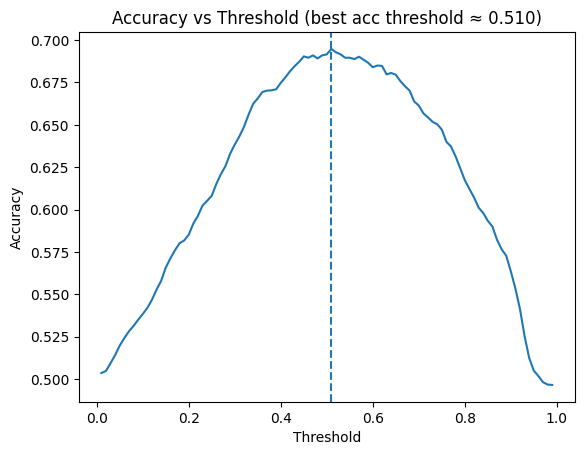

Best threshold by Accuracy: 0.51


In [160]:
# -----------------------------
# 2) Accuracy vs threshold (grid search) + plot
# -----------------------------
grid = np.linspace(0.01, 0.99, 99)
accs = []
f1_grid = []

for t in grid:
    pred = (proba_all >= t).astype(int)
    accs.append(accuracy_score(y_all, pred))
    f1_grid.append(f1_score(y_all, pred))

best_t_acc = grid[int(np.argmax(accs))]

plt.figure()
plt.plot(grid, accs)
plt.axvline(best_t_acc, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title(f"Accuracy vs Threshold (best acc threshold ≈ {best_t_acc:.3f})")
plt.show()

print("Best threshold by Accuracy:", best_t_acc)


In [144]:
thresholds = np.linspace(0.05, 0.95, 19)
best = None

for t in thresholds:
    pred = (proba_all >= t).astype(int)
    acc = accuracy_score(y_all, pred)
    f1  = f1_score(y_all, pred)
    if best is None or acc > best["acc"]:
        best = {"t": t, "acc": acc, "f1": f1}

best

{'t': np.float64(0.49999999999999994), 'acc': 0.6908, 'f1': 0.6830668306683066}

{'t': np.float64(0.44999999999999996), 'acc': 0.6484, 'f1': 0.6831290555155011}

In [149]:

# fitted pipeline: clf
pre = clf.named_steps["preprocess"]
model = clf.named_steps["model"]

# numeric feature names
num_names = list(pre.transformers_[0][2])  # ("num", ..., num_cols)

# categorical feature names after one-hot
ohe = pre.named_transformers_["cat"].named_steps["onehot"]
cat_cols = pre.transformers_[1][2]         # ("cat", ..., cat_cols)
cat_names = ohe.get_feature_names_out(cat_cols)

# all feature names in order the model sees them
feature_names = np.r_[num_names, cat_names]

coefs = model.coef_.ravel()
df_imp = pd.DataFrame({"feature": feature_names, "coef": coefs})
df_imp["abs_coef"] = df_imp["coef"].abs()

# top positive (push toward Win=1) and top negative (push toward Win=0)
top_pos = df_imp.sort_values("coef", ascending=False).head(25)
top_neg = df_imp.sort_values("coef", ascending=True).head(25)

print("Top features pushing toward Win=1:\n", top_pos[["feature","coef"]].to_string(index=False))
print("\nTop features pushing toward Win=0:\n", top_neg[["feature","coef"]].to_string(index=False))


Top features pushing toward Win=1:
                                                                            feature     coef
                                                          candidate_office_Unknown 1.255347
                                                          candidate_office_Trustee 1.164893
                                                                 office_level_City 1.077795
                                            candidate_office_Asheboro City Council 1.003783
                                                                  state_New Mexico 0.996386
                                                candidate_office_Cary Town Council 0.981625
                         candidate_office_Brunswick Water and Sewer District Board 0.925324
                                                               state_New Hampshire 0.919362
                        candidate_office_Virginia House of Delegates - District 57 0.885518
                                          ca